# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Thoriq Dhiya Aptaribowo 
- **Email:** wisma277@gmail.com
- **ID Dicoding:** thoriqdhiya

## Menentukan Pertanyaan Bisnis

- Stasiun makanah yang memliliki rata-rata konsentrasi karbon monoksida per bulan terbesar 
- Stasiun manakah yang memiliki rata-rata konsentrasi sulfur dioksida per bulan terbesar

## Import Semua Packages/Library yang Digunakan

In [11]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [12]:
path = r'Data/PRSA_Data_20130301-20170228'

files = glob.glob(os.path.join(path,"*.csv"))

df_list = [pd.read_csv(filename) for filename in files]

df = pd.concat(df_list, ignore_index=True)

**Insight:**
- Terdapat 12 file csv yang berisi data kualitas udara pada stasiun tertentu

### Assessing Data

===== Head =====
   No  year  month  day  hour  PM2.5  PM10  SO2   NO2     CO    O3  TEMP  \
0   1  2013      3    1     0    5.0  14.0  4.0  12.0  200.0  85.0  -0.5   
1   2  2013      3    1     1    8.0  12.0  6.0  14.0  200.0  84.0  -0.7   
2   3  2013      3    1     2    3.0   6.0  5.0  14.0  200.0  83.0  -1.2   
3   4  2013      3    1     3    5.0   5.0  5.0  14.0  200.0  84.0  -1.4   
4   5  2013      3    1     4    5.0   5.0  6.0  21.0  200.0  77.0  -1.9   

     PRES  DEWP  RAIN   wd  WSPM       station  
0  1024.5 -21.4   0.0  NNW   5.7  Nongzhanguan  
1  1025.1 -22.1   0.0   NW   3.9  Nongzhanguan  
2  1025.3 -24.6   0.0  NNW   5.3  Nongzhanguan  
3  1026.2 -25.5   0.0    N   4.9  Nongzhanguan  
4  1027.1 -24.5   0.0  NNW   3.2  Nongzhanguan  
===== Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-n

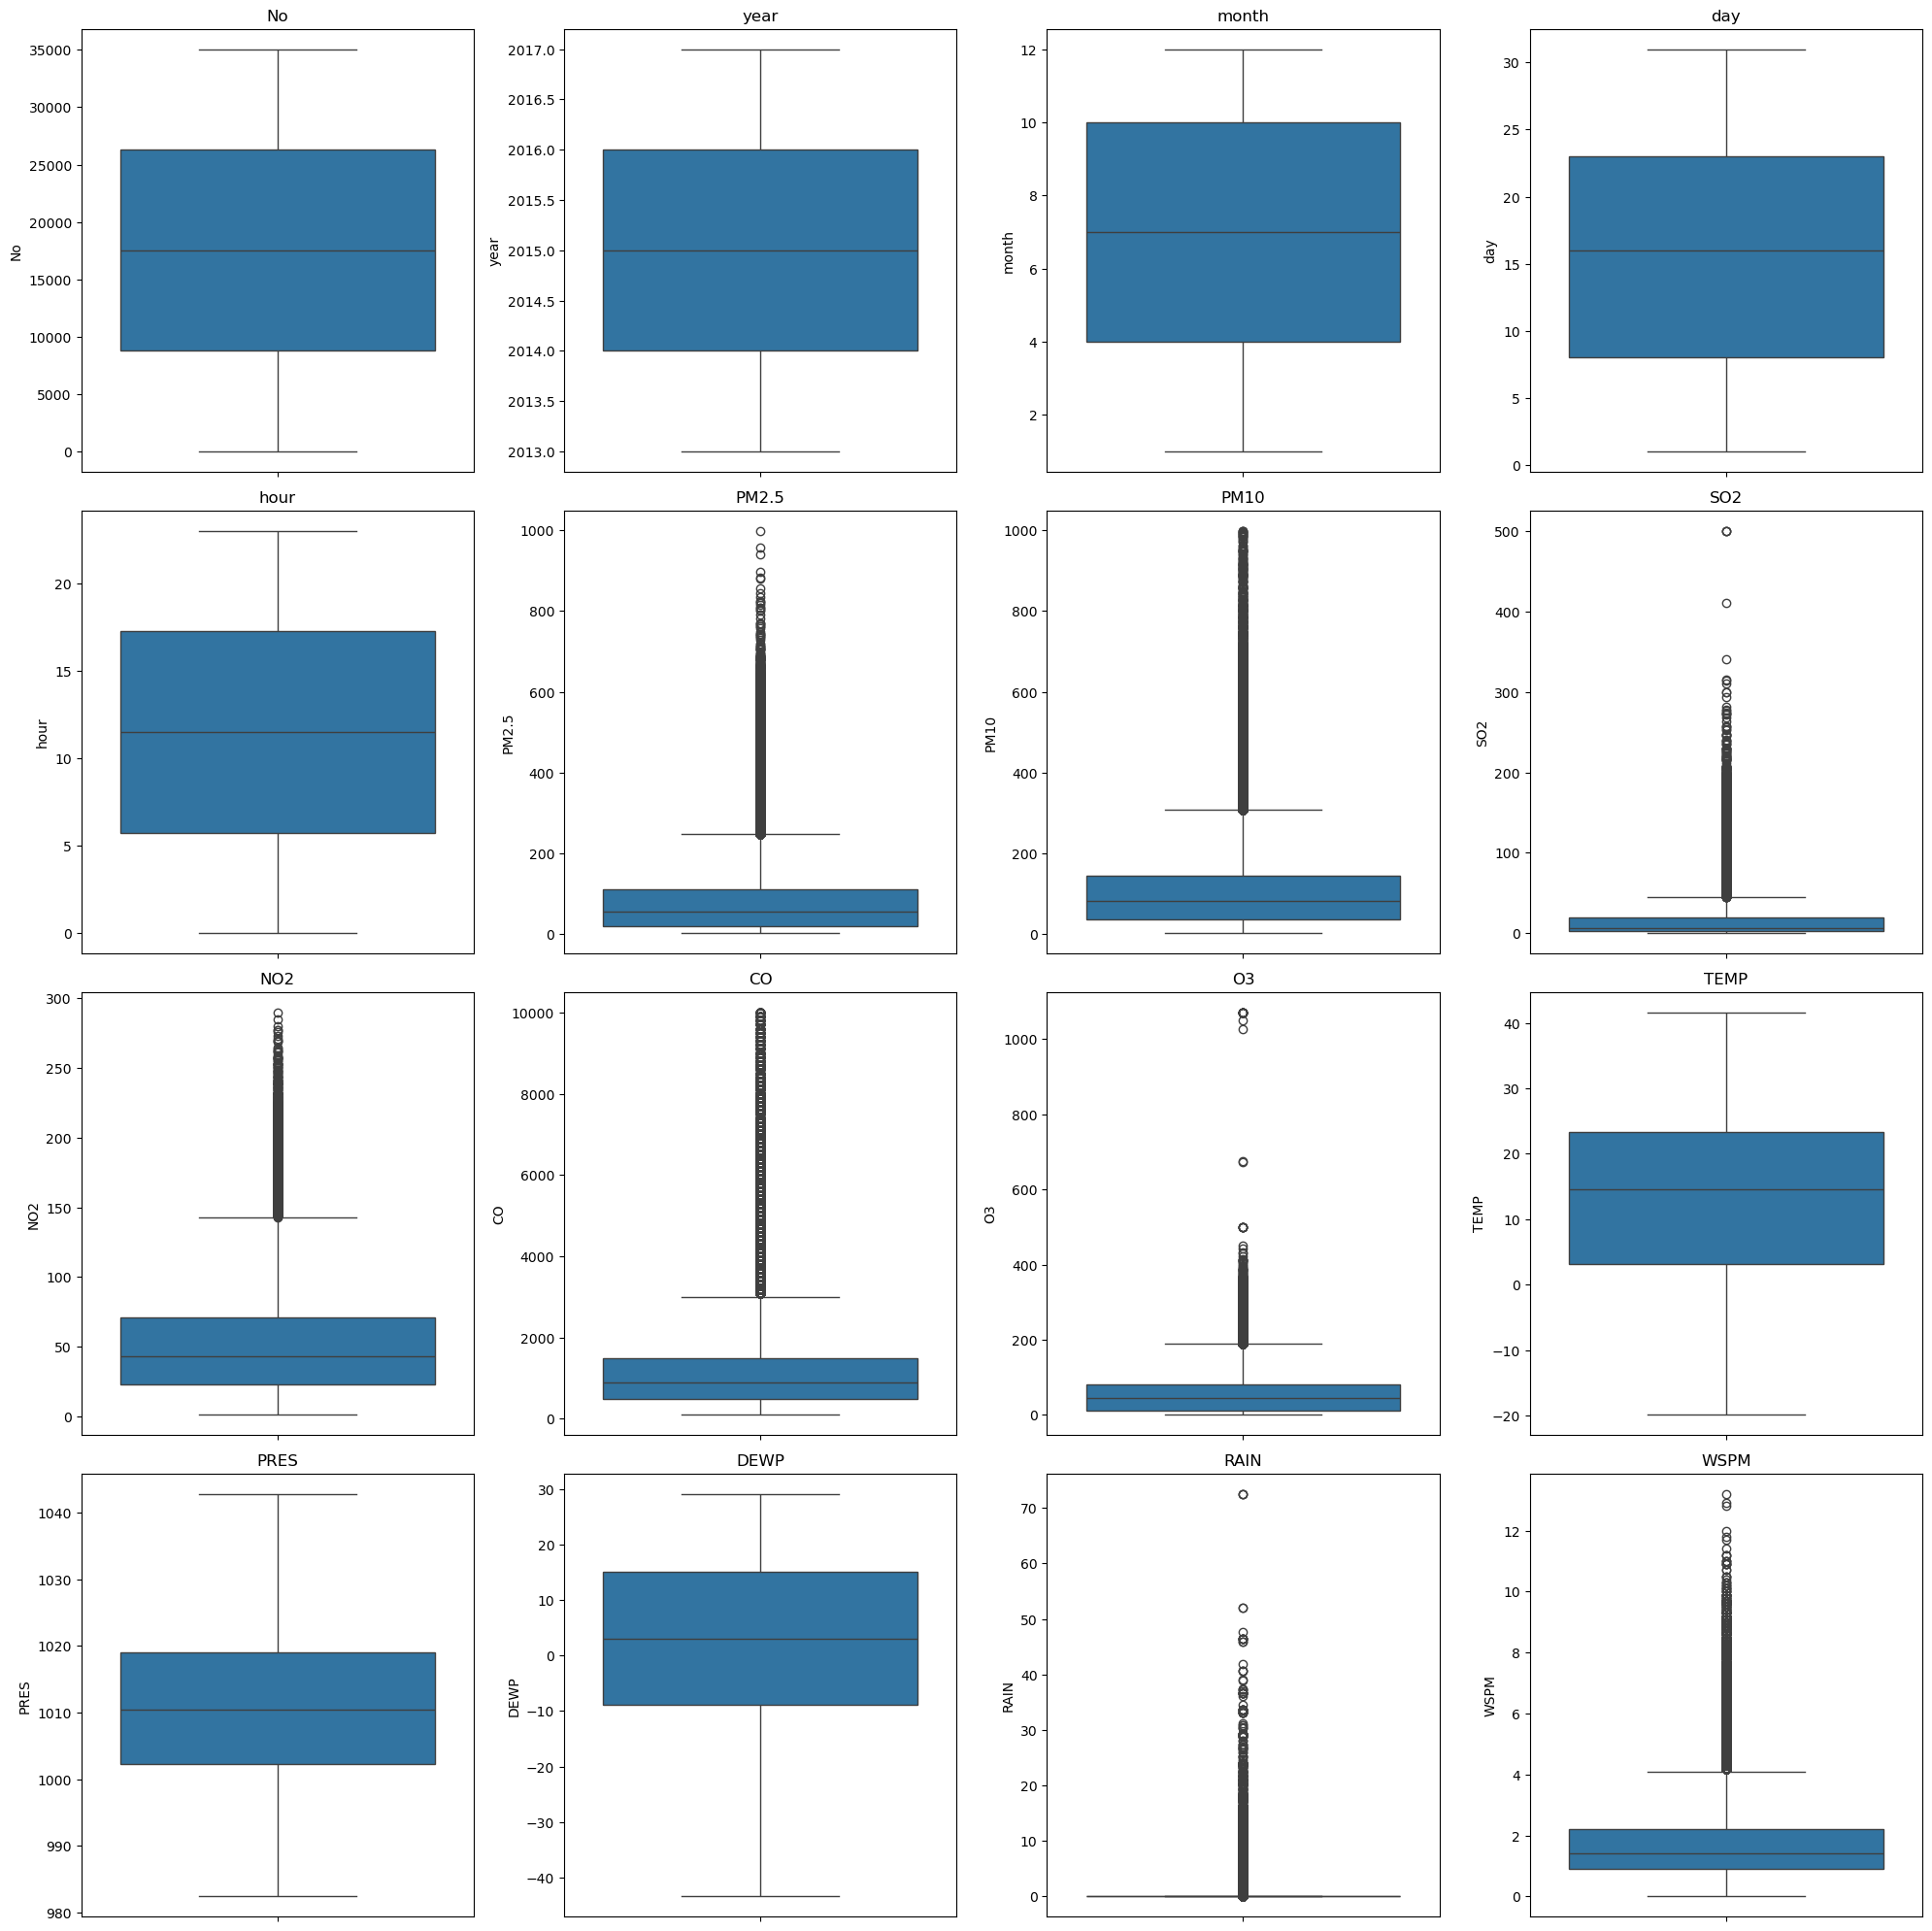

In [13]:
def create_boxplot(df):
        num_var =df.select_dtypes(include=['int64', 'float64']).columns
        n_cols = 4
        n_rows = int(np.ceil(len(num_var) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
        axes = axes.flatten()
        for i, var in enumerate(num_var):
            sns.boxplot(y=df[var], ax=axes[i])
            axes[i].set_title(var)
        plt.tight_layout()
        plt.show()

print("===== Head =====")
print(df.head())
print("===== Info =====")
print(df.info())
print("===== Describe =====")
print(df.describe(include='all'))
print("===== Duplicate =====")
print(df.duplicated().sum())
print("===== Null =====")
print(df.isnull().sum())
print("===== BoxPlot =====")
create_boxplot(df)


**Insight:**
- Tidak terdapat data duplikat dalam dataset
- Terdapat Beberapa data yang memiliki missing value
- Terdapat Outlier pada beberapa data numerik

### Cleaning Data

===== Head =====
   No  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  TEMP  \
1   2  2013      3    1     1    8.0  12.0   6.0  14.0  200.0  84.0  -0.7   
4   5  2013      3    1     4    5.0   5.0   6.0  21.0  200.0  77.0  -1.9   
5   6  2013      3    1     5    3.0   3.0  13.0  21.0  300.0  77.0  -2.4   
6   7  2013      3    1     6    4.0   4.0  15.0  32.0  300.0  62.0  -2.5   
7   8  2013      3    1     7    3.0   7.0  14.0  45.0  400.0  48.0  -1.4   

     PRES  DEWP  RAIN   wd  WSPM       station  
1  1025.1 -22.1   0.0   NW   3.9  Nongzhanguan  
4  1027.1 -24.5   0.0  NNW   3.2  Nongzhanguan  
5  1027.5 -21.3   0.0   NW   2.4  Nongzhanguan  
6  1028.2 -20.4   0.0   NW   2.2  Nongzhanguan  
7  1029.5 -20.4   0.0  NNW   3.0  Nongzhanguan  
===== Info =====
<class 'pandas.core.frame.DataFrame'>
Index: 267598 entries, 1 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       267598 non-

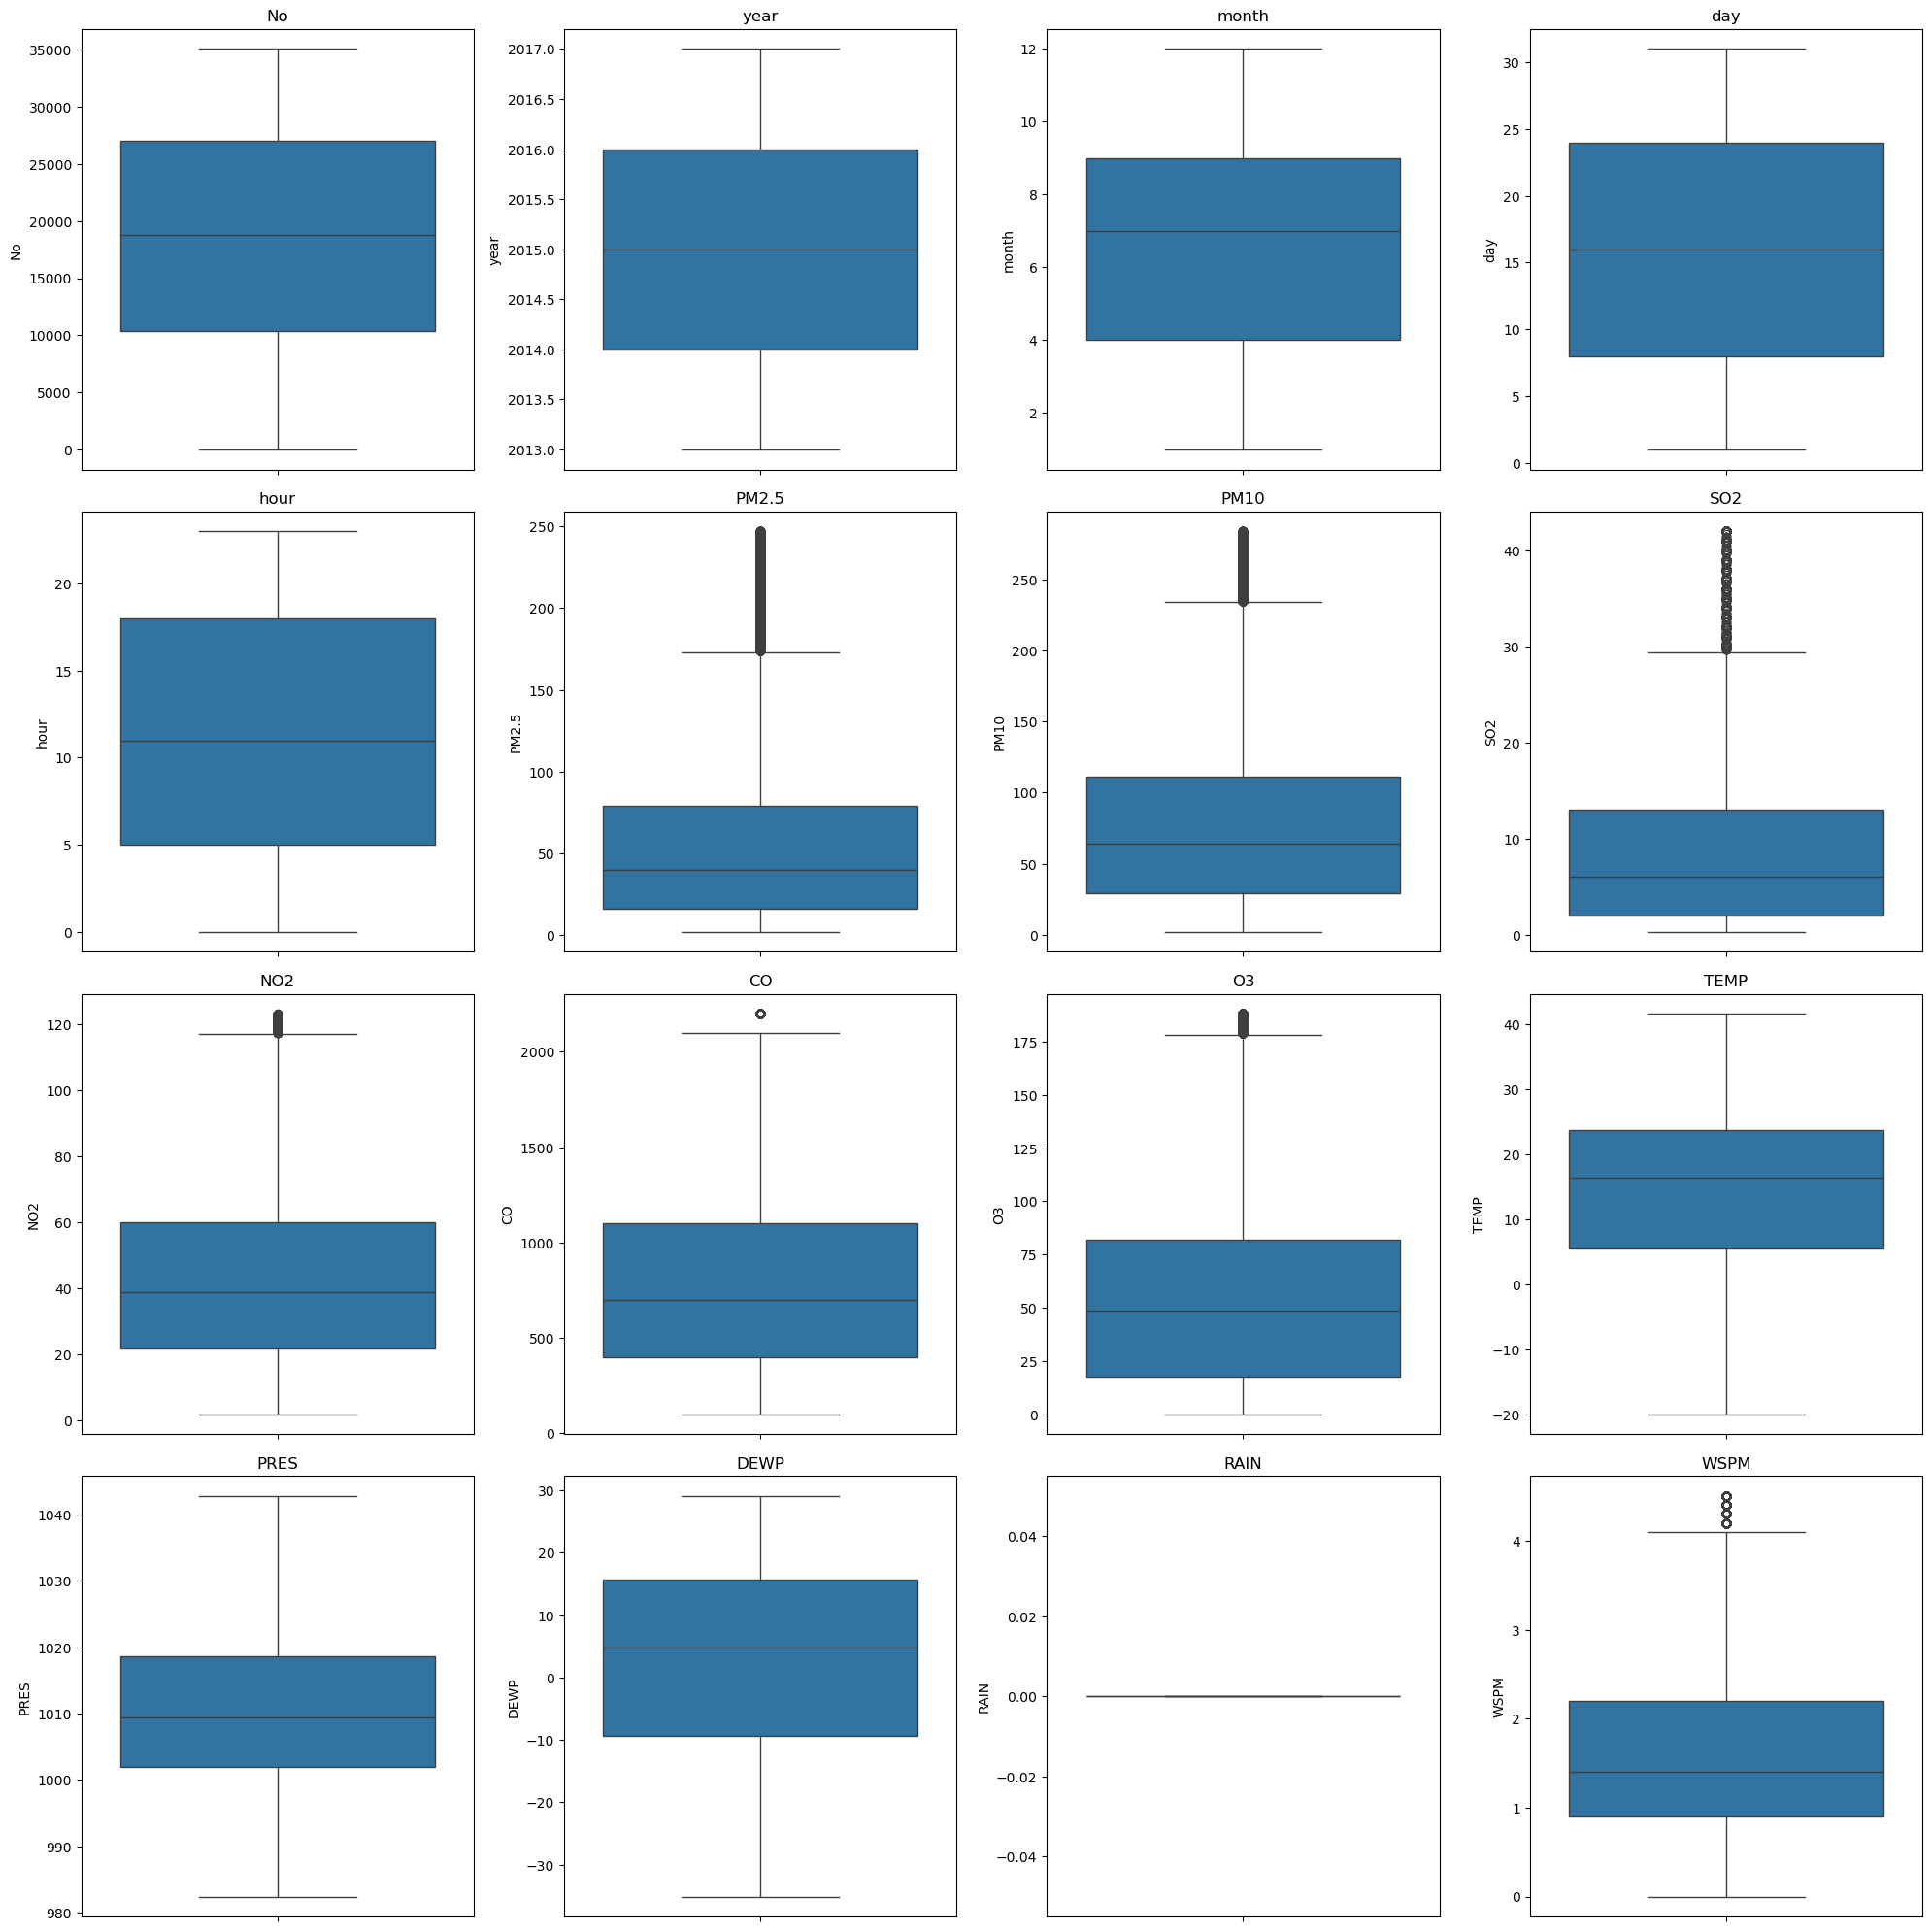

In [14]:
def clean_data(df):
    outlier = df.select_dtypes(include=['int64', 'float64']).columns
    for var in outlier:
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR
        df = df[(df[var] >= lower_bound) & (df[var] <= upper_bound)]
        df.dropna
    return df 

df_clean = clean_data(df)

print("===== Head =====")
print(df_clean.head())
print("===== Info =====")
print(df_clean.info())
print("===== Describe =====")
print(df_clean.describe(include='all'))
print("===== Duplicate =====")
print(df_clean.duplicated().sum())
print("===== Null =====")
print(df_clean.isnull().sum())
print("===== BoxPlot =====")
create_boxplot(df_clean)

**Insight:**
- xxx
- xxx

## Exploratory Data Analysis (EDA)

### Explore Kadar CO dan SO2 Per Stasiun

In [15]:
df_explore = df_clean.groupby(["station"]).agg(
    Average_CO=('CO', 'mean'),
    Average_SO2=('SO2', 'mean')
).reset_index()

df_explore

,station,Average_CO,Average_SO2
0,Aotizhongxin,803.267263,9.928070
1,Changping,797.502451,9.074645
2,Dingling,682.860106,8.523983
3,Dongsi,895.997340,10.470143
4,Guanyuan,850.036474,9.765051
5,Gucheng,866.697620,8.592386
6,Huairou,798.237898,7.824885
7,Nongzhanguan,852.292702,10.420642
8,Shunyi,815.379090,8.600413
9,Tiantan,889.888622,8.876409


**Insight:**
- Data dikelompokan berdasarkan stasiun
- Data yang diambil adalah rata rata karbon monoksida dan sulfur dioksida dari stasiun tersebut

## Visualization & Explanatory Analysis

### Pertanyaan 1:

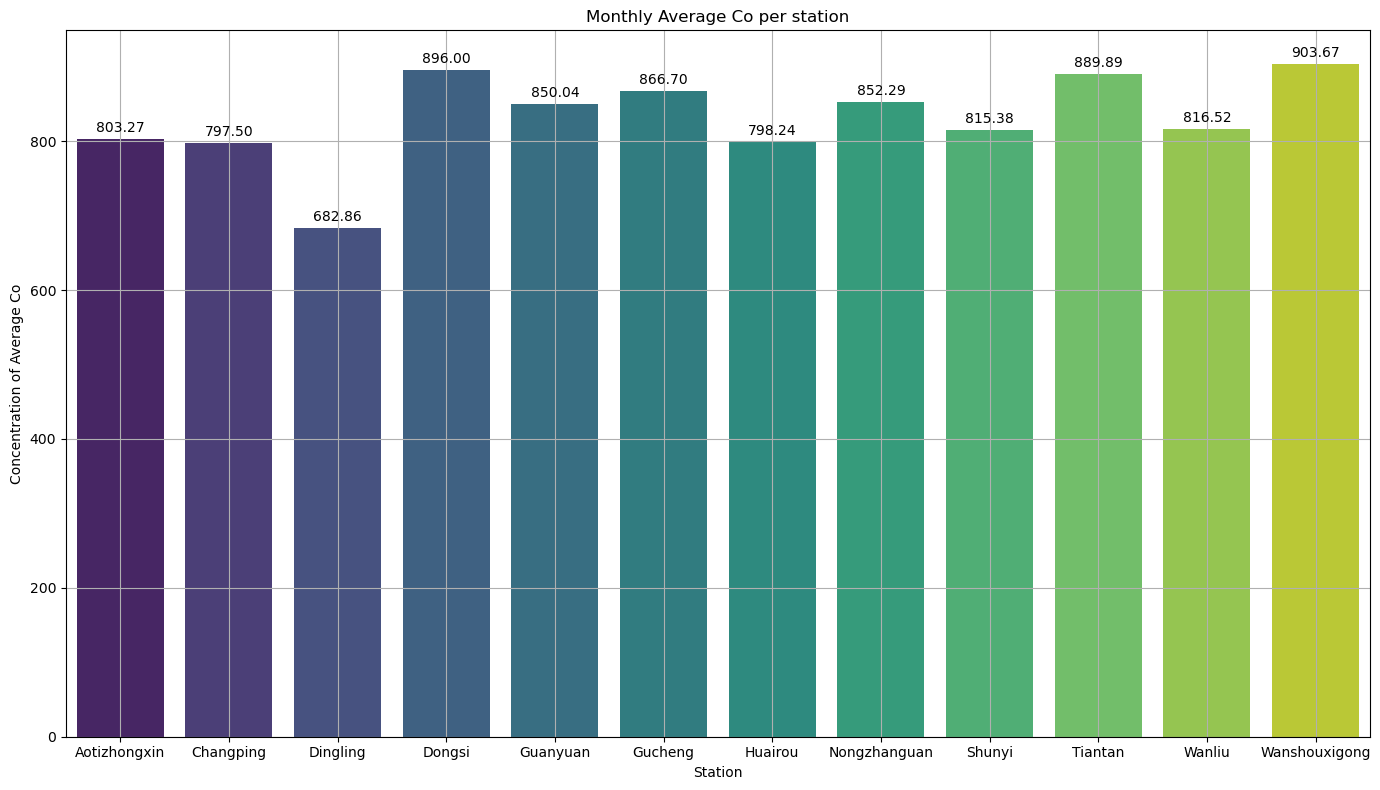

In [16]:
def plot_monthly_avg_per_station(df, y_col, x_col, figsize=(10, 6)):
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=df, x=x_col, y=y_col,hue=x_col, palette='viridis')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3) # type: ignore
    
    y_name_display = y_col.replace('_', ' ').title()

    plt.title(f"Monthly {y_name_display} per station")
    plt.xlabel(x_col.capitalize()) 
    plt.ylabel(f"Concentration of {y_name_display}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

CO_mean_col_name = 'Average_CO'
station_col_name = 'station'

plot_monthly_avg_per_station(df_explore, CO_mean_col_name, station_col_name, figsize=(14, 8))

### Pertanyaan 2:

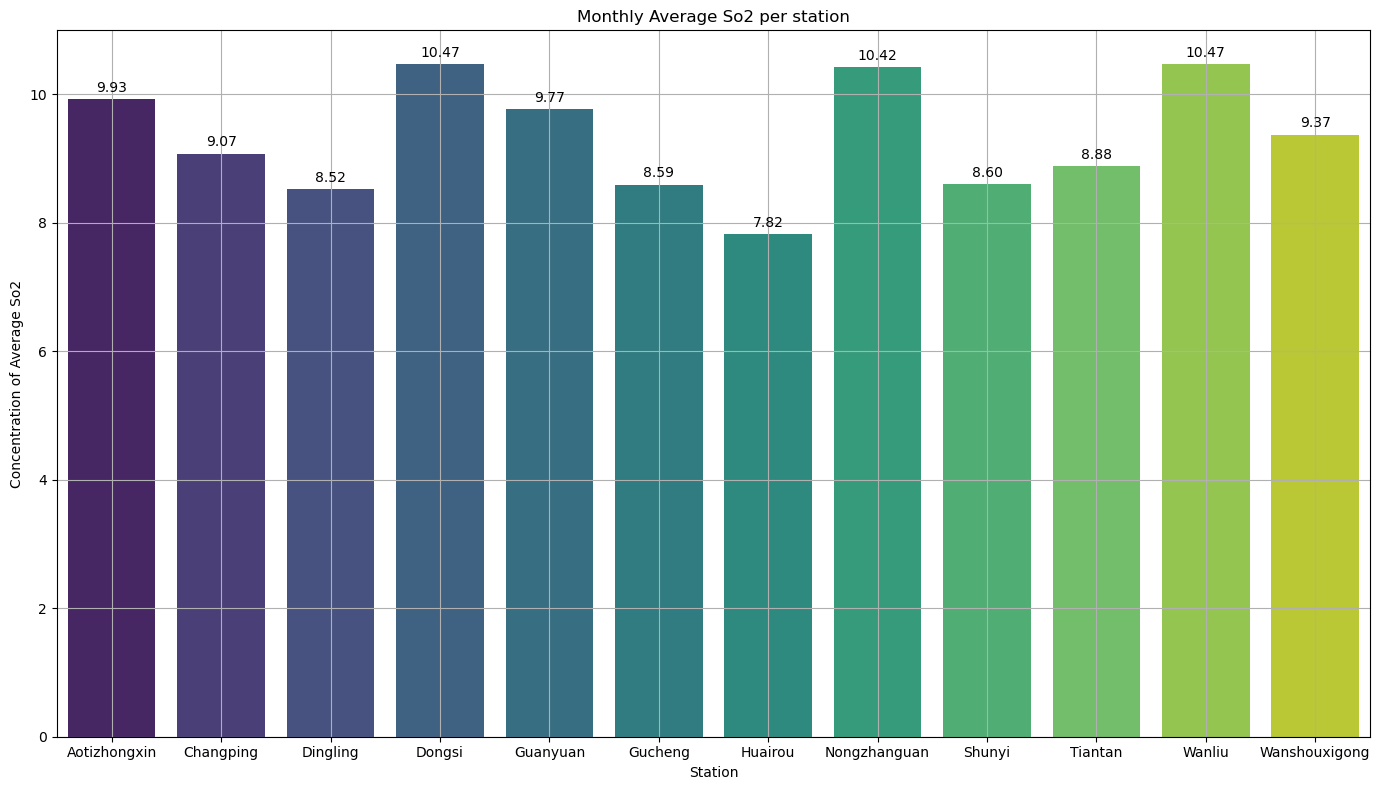

In [17]:
SO2_mean_col_name = 'Average_SO2'
station_col_name = 'station'

plot_monthly_avg_per_station(df_explore, SO2_mean_col_name, station_col_name, figsize=(14, 8))

**Insight:**
- Kadar karbon monoksida tertinggi dicatat oleh stasiun Wanshouxigong yaitu sekitar 903.67 ppm 
- Kadar sulfur dioksida tertinggi dicatat oleh stasiun Dongsi dan Wanliu yaitu sekitar 10.74 ppm

## Analisis Lanjutan (Opsional)

In [18]:
df_monthly_index = df.groupby(["station", "month"], as_index=False).agg(
    Average_CO=('CO', 'mean'),
    Average_SO2=('SO2', 'mean')
    ).reset_index()

df_monthly_index.to_csv("Dashboard/main_data.csv")
df_monthly_index

,index,station,month,Average_CO,Average_SO2
0,0,Aotizhongxin,1,1959.568641,34.923976
1,1,Aotizhongxin,2,1442.212190,31.240030
2,2,Aotizhongxin,3,1375.413529,31.748904
3,3,Aotizhongxin,4,850.421206,16.405318
4,4,Aotizhongxin,5,785.214286,16.058802
...,...,...,...,...,...
139,139,Wanshouxigong,8,987.500000,4.199956
140,140,Wanshouxigong,9,1077.791951,6.759432
141,141,Wanshouxigong,10,1276.679429,7.890503
142,142,Wanshouxigong,11,1821.922133,15.773284


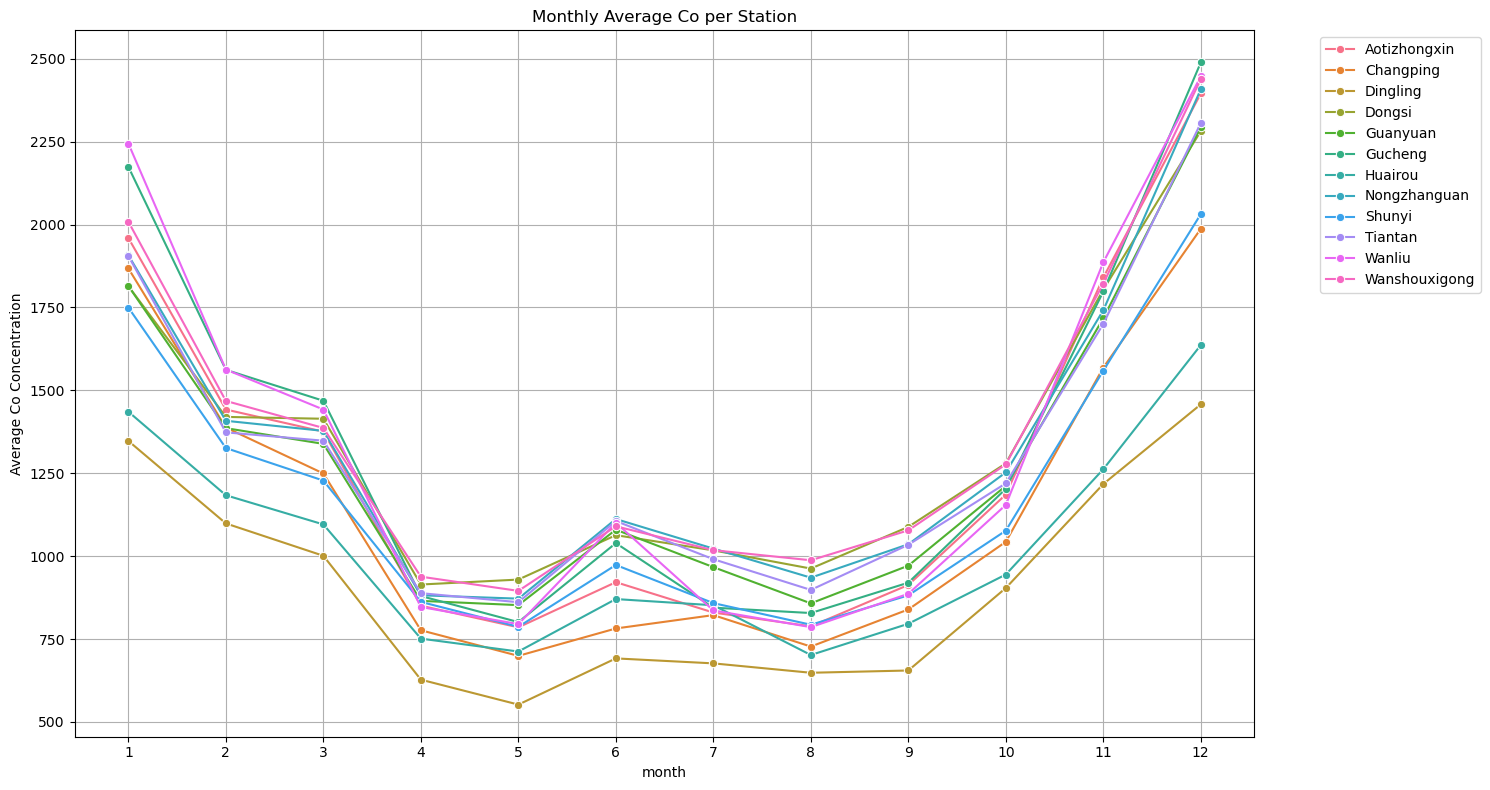

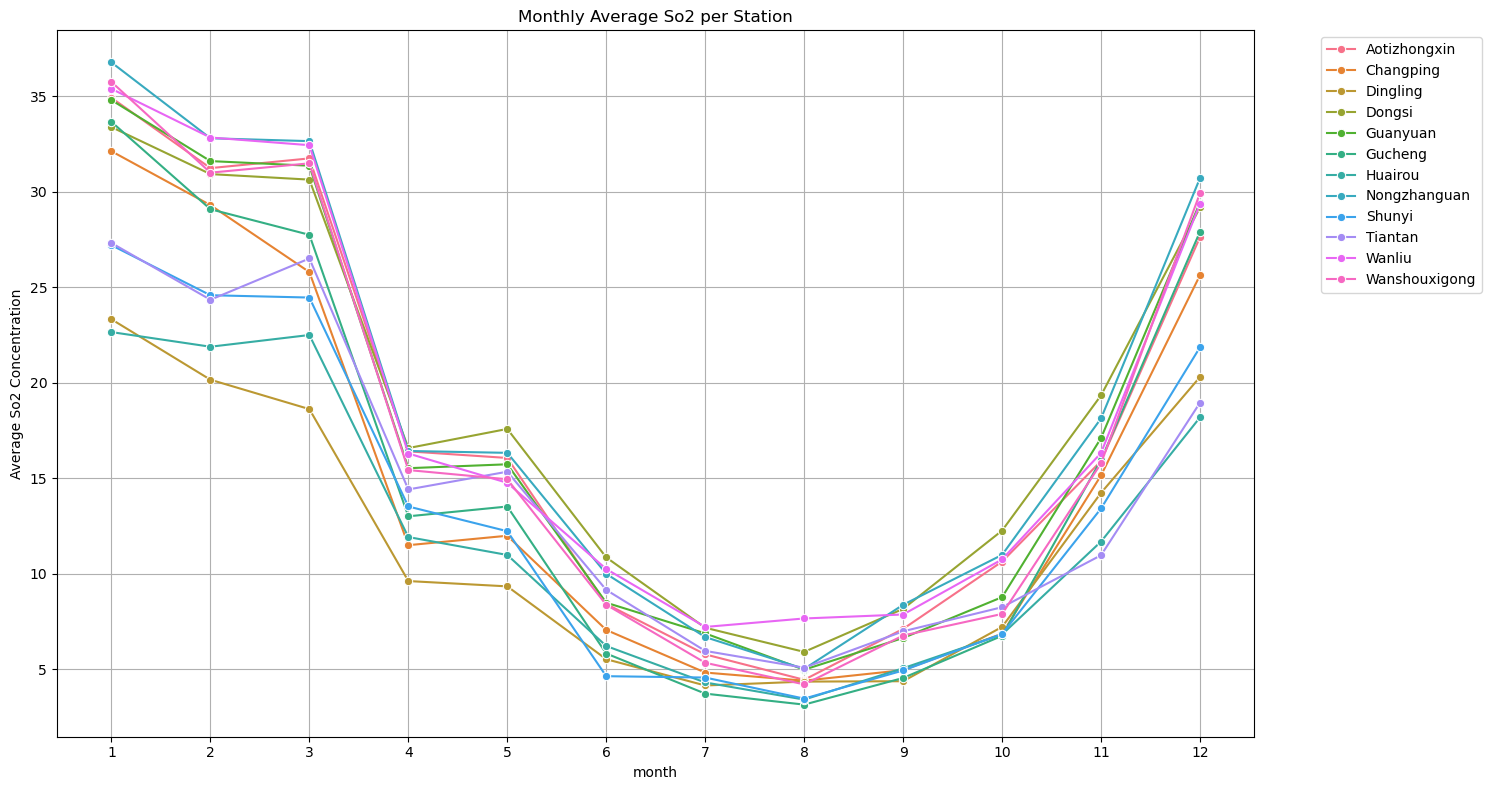

In [19]:
def line_chart(df, x, y, hue):
    plt.figure(figsize=(15, 8))
    sns.lineplot(data=df_monthly_index, x=x, y=y, hue=hue, marker='o')
    y_name_display = y.replace('_', ' ').title()
    plt.title(f'Monthly {y_name_display} per Station')
    plt.xlabel(x)
    plt.ylabel(f'{y_name_display} Concentration')
    plt.xticks(range(1, 13))
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


line_chart(df_monthly_index, 'month', 'Average_CO', 'station')
line_chart(df_monthly_index, 'month', 'Average_SO2', 'station')

## Conclusion

- Conclution pertanyaan 1
- Conclution pertanyaan 2